In [1]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline

#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

In [2]:
df_wind_montly = pd.read_csv('./2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


In [3]:
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [4]:
data = {
    "Layout_y": [9846029.731, 9846197.111, 9846323.489, 9846423.521, 9846551.776, 9846743.266, 9846862.862, 9846981.229, 9847123.455, 9847380.825, 9847736.504, 9847881.979, 9847950.427, 9847815.822, 9848019.373, 9848107.184, 9847489.094, 9847936.821, 9847820.906, 9847734.012, 9847634.116, 9847532.026, 9847397.188, 9847256.911, 9847179.492, 9847312.767, 9847411.651, 9847536.334, 9847499.008, 9847518.827],
    "Layout_x": [2376.781, 2375.137, 2361.911, 2349.034, 2334.965, 2321.065, 2317.616, 2309.323, 2295.723, 2239.071, 2222.141, 2196.289, 2186.89, 2212.672, 2179.715, 2162.664, 2183.999, 2214.963, 2230.508, 2241.077, 2239.893, 2228.47, 2243.351, 2277.398, 2296.216, 2262.404, 2237.125, 2194.764, 2201.937, 2212.847]
}

df_actual = pd.DataFrame(data)

/tmp/ipykernel_1698/2369103490.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


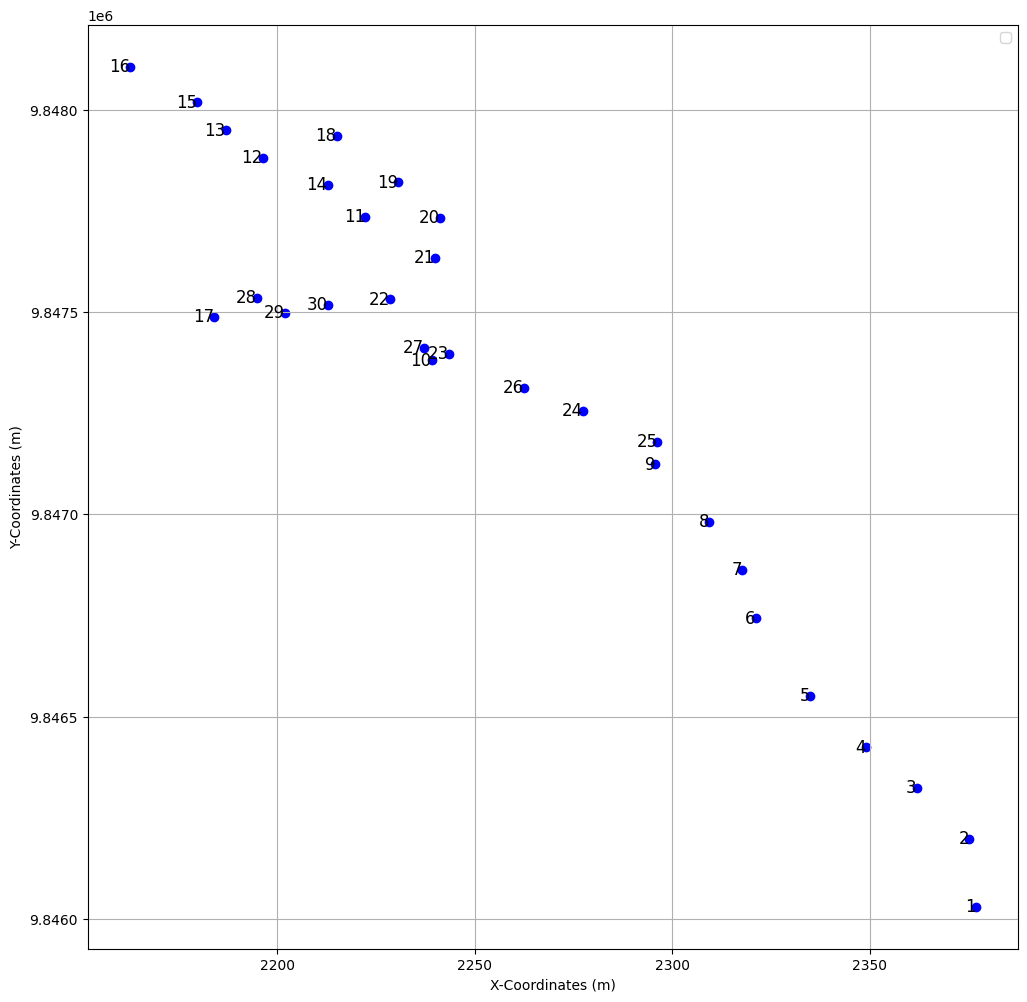

In [5]:
plt.figure(figsize=(12, 12))
plt.scatter(df_actual['Layout_x'], df_actual['Layout_y'], color='blue')
plt.grid(True)
# Add labels and title
plt.xlabel('X-Coordinates (m)')
plt.ylabel('Y-Coordinates (m)')
# plt.title('Scatter Plot')

# Add legend
plt.legend()

# Label each point with its index
for i, (x, y) in enumerate(zip(df_actual['Layout_x'], df_actual['Layout_y'])):
    plt.text(x, y, str(i+1), fontsize=12, ha='right', va='center')

# Show the plot
plt.show()

In [99]:
fi_vestas.reinitialize(
    layout_x=df_actual["Layout_x"],
    layout_y=df_actual['Layout_y'],
)
ws_array = np.arange(0,25,0.2)
fi_vestas.reinitialize(wind_speeds=ws_array)
# wd_array_1 = [270.0]
# fi_nrel.reinitialize(wind_speeds=ws_array_1)
# fi_nrel.calculate_wake(yaw_angles=yaw_angles)

In [100]:
num_wd = 1
num_ws = len(ws_array)
num_turbine = len(df_actual)
yaw_angles = np.zeros((num_wd, num_ws, num_turbine))

# Calculate
fi_vestas.calculate_wake(yaw_angles=yaw_angles)

# Collect the turbine powers
turbine_powers = fi_vestas.get_turbine_powers() / 1E3 # In kW

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


In [8]:
len(fi_vestas.get_turbine_powers()[0][0])

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


30

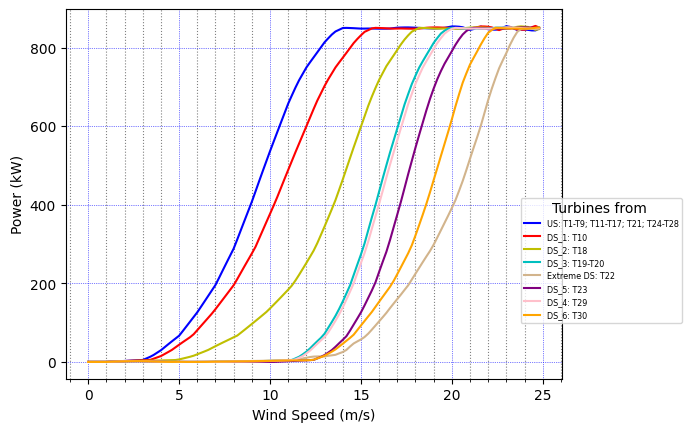

In [101]:

# Pull out the power values per turbine
pow_t0 = turbine_powers[:,:,0].flatten()
pow_t1 = turbine_powers[:,:,1].flatten()
pow_t2 = turbine_powers[:,:,2].flatten()
pow_t3 = turbine_powers[:,:,3].flatten()
pow_t4 = turbine_powers[:,:,4].flatten()
pow_t5 = turbine_powers[:,:,5].flatten()
pow_t6 = turbine_powers[:,:,6].flatten()
pow_t7 = turbine_powers[:,:,7].flatten()
pow_t8 = turbine_powers[:,:,8].flatten()
pow_t9 = turbine_powers[:,:,9].flatten()
pow_t10 = turbine_powers[:,:,10].flatten()
pow_t11 = turbine_powers[:,:,11].flatten()
pow_t12 = turbine_powers[:,:,12].flatten()
pow_t13 = turbine_powers[:,:,13].flatten()
pow_t14 = turbine_powers[:,:,14].flatten()
pow_t15 = turbine_powers[:,:,15].flatten()
pow_t16 = turbine_powers[:,:,16].flatten()
pow_t17 = turbine_powers[:,:,17].flatten()
pow_t18 = turbine_powers[:,:,18].flatten()
pow_t19 = turbine_powers[:,:,19].flatten()
pow_t20 = turbine_powers[:,:,20].flatten()
pow_t21 = turbine_powers[:,:,21].flatten()
pow_t22 = turbine_powers[:,:,22].flatten()
pow_t23 = turbine_powers[:,:,23].flatten()
pow_t24 = turbine_powers[:,:,24].flatten()
pow_t25 = turbine_powers[:,:,25].flatten()
pow_t26 = turbine_powers[:,:,26].flatten()
pow_t27 = turbine_powers[:,:,27].flatten()
pow_t28 = turbine_powers[:,:,28].flatten()
pow_t29 = turbine_powers[:,:,29].flatten()
# pow_t30 = turbine_powers[:,:,30].flatten()
# pow_t31 = turbine_powers[:,:,31].flatten()
# pow_t32 = turbine_powers[:,:,32].flatten()
# pow_t33 = turbine_powers[:,:,33].flatten()
# pow_t34 = turbine_powers[:,:,34].flatten()
# pow_t35 = turbine_powers[:,:,35].flatten()
# pow_t36 = turbine_powers[:,:,36].flatten()
# pow_t37 = turbine_powers[:,:,37].flatten()
# pow_t38 = turbine_powers[:,:,38].flatten()
# pow_t39 = turbine_powers[:,:,39].flatten()
# pow_t40 = turbine_powers[:,:,40].flatten()
# pow_t41 = turbine_powers[:,:,41].flatten()
# pow_t42 = turbine_powers[:,:,42].flatten()
# pow_t43 = turbine_powers[:,:,43].flatten()
# pow_t44 = turbine_powers[:,:,44].flatten()

# Plot
# Plot
fig, ax = plt.subplots()
ax.plot(ws_array,pow_t0,color='b', label='US: T1-T9; T11-T17; T21; T24-T28')
# ax.plot(ws_array,pow_t1)
# ax.plot(ws_array,pow_t2)
# ax.plot(ws_array,pow_t3)
# ax.plot(ws_array,pow_t4)
# ax.plot(ws_array,pow_t15,color='y')
# ax.plot(ws_array,pow_t5,color='r')
# ax.plot(ws_array,pow_t6)
# ax.plot(ws_array,pow_t7)
# ax.plot(ws_array,pow_t8)
ax.plot(ws_array,pow_t9,color='r', label='DS_1: T10')
# ax.plot(ws_array,pow_t10)
# ax.plot(ws_array,pow_t11)
# ax.plot(ws_array,pow_t12)
# ax.plot(ws_array,pow_t13)
# ax.plot(ws_array,pow_t14)
# ax.plot(ws_array,pow_t16)
ax.plot(ws_array,pow_t17,color='y', label='DS_2: T18')
ax.plot(ws_array,pow_t18,color='c', label='DS_3: T19-T20')
# ax.plot(ws_array,pow_t19,color='c')
# ax.plot(ws_array,pow_t20)
ax.plot(ws_array,pow_t21,color='tan', label='Extreme DS: T22')
ax.plot(ws_array,pow_t22,color='purple', label='DS_5: T23')
# ax.plot(ws_array,pow_t23)
# ax.plot(ws_array,pow_t24)
# ax.plot(ws_array,pow_t25)
# ax.plot(ws_array,pow_t26)
# ax.plot(ws_array,pow_t27,color='b')
ax.plot(ws_array,pow_t28,color='pink', label='DS_4: T29')
ax.plot(ws_array,pow_t29,color='orange', label='DS_6: T30')
# ax.plot(ws_array,pow_t30,color='b')
# ax.plot(ws_array,pow_t31,color='y')
# ax.plot(ws_array,pow_t32,color='b')
# ax.plot(ws_array,pow_t33,color='b')
# ax.plot(ws_array,pow_t34,color='b')
# ax.plot(ws_array,pow_t35,color='b')
# ax.plot(ws_array,pow_t36,color='b')
# ax.plot(ws_array,pow_t37,color='r')
# ax.plot(ws_array,pow_t38,color='b')
# ax.plot(ws_array,pow_t39,color='b')
# ax.plot(ws_array,pow_t40,color='r')
# ax.plot(ws_array,pow_t41,color='b')
# ax.plot(ws_array,pow_t42,color='b')
# ax.plot(ws_array,pow_t43,color='b')
# ax.plot(ws_array,pow_t44,color='r')


# ax.grid(True)
plt.grid(which='major', linestyle=':', linewidth='0.5', color='blue')
# plt.grid(which='minor', linestyle=':', linewidth='0.5', color='red')
# # Add labels to each line
# lines, labels = ax.get_legend_handles_labels()
# unique_labels = list(set(labels))
# unique_labels.sort()

# Create a single legend with labels underneath the duplicate lines
ax.legend( loc='upper right', bbox_to_anchor=(1.25, 0.5), fontsize='xx-small', title='Turbines from ', title_fontsize='medium')

ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (kW)')

plt.grid(which='minor', linestyle=':', linewidth='0.8', color='gray', axis='x')  # Minor gridlines on x-axis only
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(1))

plt.show()